<a href="https://colab.research.google.com/github/samiha-mahin/Covid-19_Machine_Learning/blob/main/covid19_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/covid_selected_features.csv')

In [3]:
df.head()

,Abroad travel,Attended Large Gathering,Sore throat,Breathing Problem,Contact with COVID Patient,Dry Cough,Fever,Family working in Public Exposed Places,Visited Public Exposed Places,Hyper Tension,Asthma,Chronic Lung Disease,Fatigue,Diabetes,COVID-19
0,0,0,1,1,1,1,1,1,1,1,0,0,1,1,1
1,0,1,1,1,0,1,1,0,1,0,1,1,1,0,1
2,1,0,1,1,0,1,1,0,0,0,1,1,1,1,1
3,1,1,0,1,0,1,1,0,1,0,1,0,0,1,1
4,0,0,1,1,1,1,1,0,1,1,0,1,0,1,1


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('COVID-19', axis=1)
y = df['COVID-19']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **Applying smote in train set to the train set to fix the class imbalance**

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


# **RandomForestClassifier**

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=None,
    class_weight=None  # NOT needed since SMOTE already balanced
)

rf_model.fit(X_train_sm, y_train_sm)


RandomForestClassifier(n_estimators=200, random_state=42)

In [9]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9806807727690893

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       210
           1       1.00      0.98      0.99       877

    accuracy                           0.98      1087
   macro avg       0.95      0.99      0.97      1087
weighted avg       0.98      0.98      0.98      1087



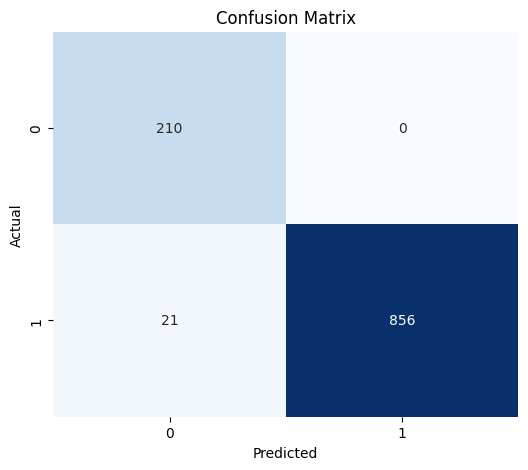

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


## **5-Fold Cross-Validation**

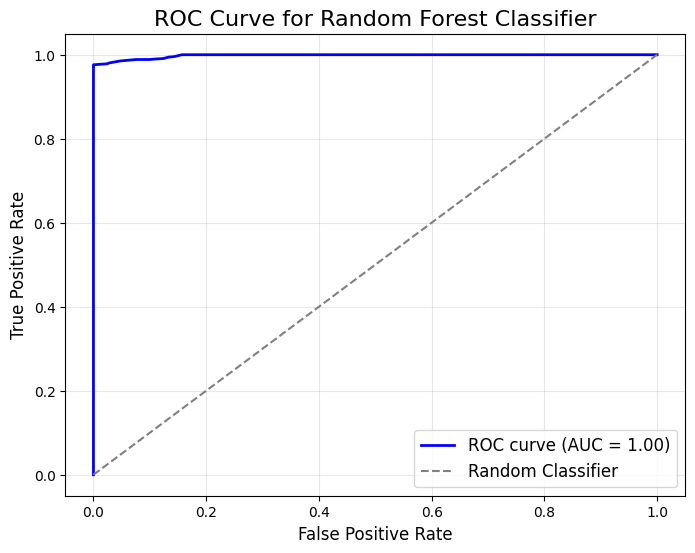

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Fancy plot
plt.figure(figsize=(8,6))

# Plot the ROC curve
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# Diagonal line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')

# Titles & labels
plt.title('ROC Curve for Random Forest Classifier', fontsize=16,)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)

plt.show()

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# Use the selected features dataframe
X = df.drop(columns=['COVID-19'])
y = df['COVID-19']

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# 5-Fold Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
fold_auc = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Optional: Apply SMOTE only on training set
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    # Train
    rf_model.fit(X_train_sm, y_train_sm)

    # Predict
    y_pred = rf_model.predict(X_test)
    y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)

    fold_accuracies.append(acc)
    fold_auc.append(auc_score)

    print(f"Fold {fold}: Accuracy = {acc:.4f}, AUC = {auc_score:.4f}")

# Overall mean performance
print(f"\nMean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Mean AUC: {np.mean(fold_auc):.4f}")


Fold 1: Accuracy = 0.9798, AUC = 0.9979
Fold 2: Accuracy = 0.9761, AUC = 0.9987
Fold 3: Accuracy = 0.9844, AUC = 0.9982
Fold 4: Accuracy = 0.9798, AUC = 0.9977
Fold 5: Accuracy = 0.9825, AUC = 0.9976

Mean Accuracy: 0.9805
Mean AUC: 0.9980


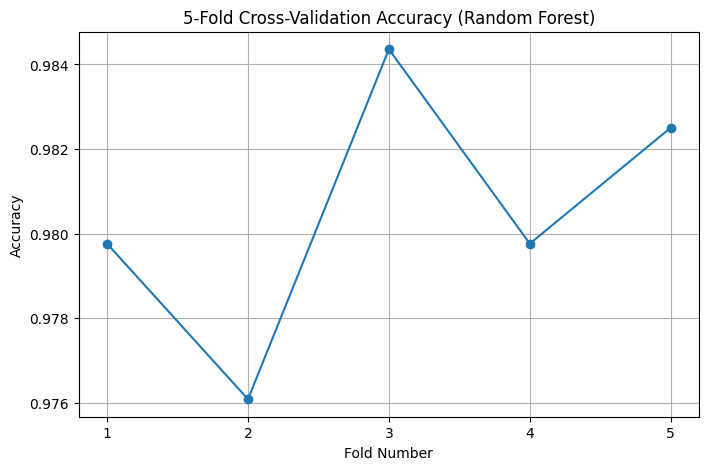

In [33]:
import matplotlib.pyplot as plt
import numpy as np

folds = np.arange(1, len(fold_accuracies) + 1)

plt.figure(figsize=(8, 5))
plt.plot(folds, fold_accuracies, marker='o', linestyle='-')
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy (Random Forest)")
plt.xticks(folds)
plt.grid(True)
plt.show()